# W03 Sequence Models — RNN vs Transformer

**Platform:** Aido Rover (LSTM / GRU / Transformer-encoder anomaly detection)  
**Seed:** 42 · **Sampling rate:** 10 Hz · **Gate:** ≤100 ms

Pipeline: Week-2 windowed tensor + canonical fold ids (§1) → quantitative window-size choice (§2) → shared protocol (§3) → LSTM/GRU (§4), Transformer encoder (§5) → head-to-head: convergence, 7-fold rotation, data efficiency, latency-vs-window (§6) → attention interpretability vs ground truth (§7) → ledger append (§8). Full analysis: `reports/W03_Sequence_Comparison_Report.md`.

In [1]:

import copy
import sys
import timeit
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, f1_score)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_DIR = Path('../data')
IMG_DIR = Path('../reports/image/W03_Sequence_Models_RNN_vs_Transformer')
IMG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

CONSTRAINT_MS = 100.0   # Aido Rover general feasibility gate, 10 Hz streaming
print(f'Device (training): {DEVICE}')

ledger_path = DATA_DIR / 'model_ledger.csv'
ledger_df_ref = pd.read_csv(ledger_path)
print('Current model_ledger.csv:')
ledger_df_ref[['week', 'model', 'latency_ms', 'f1_test', 'f1_test_std', 'auc_test', 'verdict']]


Device (training): cuda
Current model_ledger.csv:


,week,model,latency_ms,f1_test,f1_test_std,auc_test,verdict
0,2,RandomForest,7.8560,0.7492,0.0481,0.9595,PASS
1,3,MLP,0.1351,0.7936,0.0472,0.9786,PASS
2,3,1D-CNN,0.1516,0.7307,0.1147,0.9648,PASS
3,3,LSTM,0.1909,0.7038,0.1590,0.9694,PASS
4,3,GRU,0.6659,0.7468,0.0818,0.9747,PASS
5,3,Transformer,0.5191,0.8289,0.0688,0.9822,PASS


## 1. Data — Windowed Sequence Tensor + Canonical Fold Ids

Loaded directly from `rover_windows.npz` (built in `W02_Sequence_and_RL_Scaffolding.ipynb`). Three window
lengths are available (10 / 20 / 50 steps); §2 below picks the main-experiment length quantitatively. Each
array is `(N, steps, 11 channels)` — already `(batch, seq, channel)`-ordered, matching what
`nn.LSTM`/`nn.GRU`/`nn.TransformerEncoder` expect with `batch_first=True`.

In [2]:

windows = np.load(DATA_DIR / 'rover_windows.npz')
SENSOR_COLS = list(windows['sensor_col_names'])
N_CHANNELS = len(SENSOR_COLS)
print(f'Channels ({N_CHANNELS}): {SENSOR_COLS}')

WSIZES = [10, 20, 50]
Xw = {w: {'train': windows[f'X_train_w{w}'], 'val': windows[f'X_val_w{w}'], 'test': windows[f'X_test_w{w}']}
      for w in WSIZES}
yw = {'train': windows['y_train'].astype(np.int64),
      'val': windows['y_val'].astype(np.int64),
      'test': windows['y_test'].astype(np.int64)}
fold_id = {'train': windows['fold_id_train'], 'val': windows['fold_id_val'], 'test': windows['fold_id_test']}

print('\nSequence tensor shapes (canonical block split):')
for w in WSIZES:
    print(f'  w={w:2d}: train={Xw[w]["train"].shape}  val={Xw[w]["val"].shape}  test={Xw[w]["test"].shape}')
for name, y in yw.items():
    print(f'  {name:5s} anomaly rate: {y.mean()*100:.1f}%  (n={len(y):,})')

# concatenated (raw, unnormalized) + fold ids per window size, for the 7-fold rotation (§6.2)
Xw_all = {w: np.concatenate([Xw[w]['train'], Xw[w]['val'], Xw[w]['test']], axis=0) for w in WSIZES}
y_all = np.concatenate([yw['train'], yw['val'], yw['test']], axis=0)
fold_id_all = np.concatenate([fold_id['train'], fold_id['val'], fold_id['test']], axis=0)
print(f'\nConcatenated for 7-fold rotation: {Xw_all[50].shape}, unique folds={sorted(np.unique(fold_id_all).tolist())}')


Channels (11): [np.str_('gps_dlat'), np.str_('gps_dlon'), np.str_('lidar_distance'), np.str_('battery_soc'), np.str_('torque_0'), np.str_('torque_1'), np.str_('torque_2'), np.str_('torque_3'), np.str_('ambient_temp'), np.str_('inter_wheel_std'), np.str_('stall_ratio')]

Sequence tensor shapes (canonical block split):
  w=10: train=(9734, 10, 11)  val=(2215, 10, 11)  test=(1901, 10, 11)
  w=20: train=(9734, 20, 11)  val=(2215, 20, 11)  test=(1901, 20, 11)
  w=50: train=(9734, 50, 11)  val=(2215, 50, 11)  test=(1901, 50, 11)
  train anomaly rate: 16.4%  (n=9,734)
  val   anomaly rate: 16.0%  (n=2,215)
  test  anomaly rate: 16.0%  (n=1,901)

Concatenated for 7-fold rotation: (13850, 50, 11), unique folds=[0, 1, 2, 3, 4, 5, 6]


## 2. Window-Size Justification (Quantitative)

The anomaly-duration distribution is computed directly from the causal fault generator's run-lengths in
`synthetic_rover_data.csv` (consecutive `anomaly_label==1` runs).

In [3]:
df_lbl = pd.read_csv(DATA_DIR / 'synthetic_rover_data.csv', index_col='timestamp', parse_dates=True)
lbl = df_lbl['anomaly_label'].values

runs, count = [], 0
for v in lbl:
    if v == 1:
        count += 1
    else:
        if count > 0:
            runs.append(count)
        count = 0
if count > 0:
    runs.append(count)
runs = np.array(runs)

FS = 10.0  # Hz
print(f'Anomaly run-lengths: n={len(runs)}  mean={runs.mean():.2f} steps ({runs.mean()/FS:.2f} s)  '
      f'median={np.median(runs):.1f} steps ({np.median(runs)/FS:.2f} s)  '
      f'min={runs.min()} steps ({runs.min()/FS:.2f} s)  max={runs.max()} steps ({runs.max()/FS:.2f} s)')

window_table = pd.DataFrame({
    'window_steps': WSIZES,
    'window_seconds': [w / FS for w in WSIZES],
    'vs_mean_duration': [f'{w/FS:.1f}s vs {runs.mean()/FS:.2f}s mean' for w in WSIZES],
    'runs_fully_contained': [f'{(runs <= w).mean()*100:.1f}%' for w in WSIZES],
})
print(window_table.to_string(index=False))

Anomaly run-lengths: n=72  mean=31.36 steps (3.14 s)  median=27.5 steps (2.75 s)  min=10 steps (1.00 s)  max=78 steps (7.80 s)
 window_steps  window_seconds   vs_mean_duration runs_fully_contained
           10             1.0 1.0s vs 3.14s mean                 2.8%
           20             2.0 2.0s vs 3.14s mean                30.6%
           50             5.0 5.0s vs 3.14s mean                87.5%


**w=50 (5 s) for all main experiments.** A window fully contains 2.8% (w=10) / 30.6% (w=20) / 87.5% (w=50) of observed fault runs — only w=50 sees most faults whole, and even the 7.8 s tail leaves it 5 s of in-fault evidence. w=10/20 are reused only as latency variables (§6.4).

**Label = the anchor step's `anomaly_label`** — the step immediately after the buffer (W02 `make_windows`: features rows `[i−50, i)`, label row `i`): "is the rover in a fault state *now*", not "did the buffer contain an anomaly". An anomalous window may hold 0–50 in-window fault steps (quantified in §7.1). Hence many-to-one heads: RNNs read the final hidden state, the Transformer mean-pools.

## 3. Shared Training Infrastructure

Class-weighted cross-entropy, Adam(lr=1e-3), batch 128, ≤100 epochs, early stopping on val loss (patience 10, best checkpoint restored); test predictions use a val-tuned decision threshold — the same protocol as the W03 first half. No per-model optimiser ablation: protocol parity keeps architecture the only variable.

In [4]:

def class_weight_tensor(y, device):
    classes, counts = np.unique(y, return_counts=True)
    w = counts.sum() / (len(classes) * counts)
    return torch.tensor(w, dtype=torch.float32, device=device)


def make_loader(X, y, batch_size=128, shuffle=True):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def _eval_split(model, X, y, criterion, device):
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(X, dtype=torch.float32, device=device)
        yt = torch.tensor(y, dtype=torch.long, device=device)
        out = model(Xt)
        loss = criterion(out, yt).item()
        f1 = f1_score(y, out.argmax(1).cpu().numpy())
    return loss, f1


def train_with_early_stopping(model, train_loader, X_tr, y_tr, X_va, y_va, criterion, optimizer,
                               device, max_epochs=100, patience=10):
    model.to(device)
    best_val_loss = np.inf
    best_state = None
    best_epoch = -1
    n_bad = 0
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    n_epochs_run = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        train_loss, train_f1 = _eval_split(model, X_tr, y_tr, criterion, device)
        val_loss, val_f1 = _eval_split(model, X_va, y_va, criterion, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        n_epochs_run = epoch + 1

        if val_loss < best_val_loss - 1e-5:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            n_bad = 0
        else:
            n_bad += 1
            if n_bad >= patience:
                break

    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return model, history, n_epochs_run


def tune_threshold(y_val, proba_val, grid=None):
    """Val-tuned decision threshold (max anomaly-F1 on val), applied unchanged to test — same
    protocol as the RF/MLP/CNN baselines."""
    if grid is None:
        grid = np.linspace(0.05, 0.95, 91)
    f1s = [f1_score(y_val, (proba_val >= t).astype(int)) for t in grid]
    best_i = int(np.argmax(f1s))
    return float(grid[best_i]), float(f1s[best_i])


def standardize_channels(X_train_raw):
    """Per-channel mean/std fit on the given (train) array; shape (..., channels) — last axis."""
    ch_mean = X_train_raw.reshape(-1, X_train_raw.shape[-1]).mean(0)
    ch_std = X_train_raw.reshape(-1, X_train_raw.shape[-1]).std(0) + 1e-8
    return ch_mean, ch_std


def apply_standardize(X, ch_mean, ch_std):
    return ((X - ch_mean) / ch_std).astype(np.float32)


def predict_proba(model, X, device):
    model.eval()
    with torch.no_grad():
        out = model(torch.tensor(X, dtype=torch.float32, device=device))
        return torch.softmax(out, dim=1)[:, 1].cpu().numpy()


def measure_latency(model, x_single, x_batch, n_reps=100):
    model_cpu = copy.deepcopy(model).to('cpu').eval()
    with torch.no_grad():
        for _ in range(10):   # warm-up: first calls on a fresh copy pay one-off kernel/packing costs
            model_cpu(x_single)
        single_ms = timeit.timeit(lambda: model_cpu(x_single), number=n_reps) / n_reps * 1000
        for _ in range(3):
            model_cpu(x_batch)
        batch_ms = timeit.timeit(lambda: model_cpu(x_batch), number=n_reps) / n_reps * 1000
    return single_ms, batch_ms


N_REPS = 100
print('Shared training/eval/latency helpers defined.')


Shared training/eval/latency helpers defined.


## 4. LSTM & GRU

Single-layer **unidirectional** recurrent units, hidden 64 (capacity-matched to the MLP's first layer and the Transformer's d_model), dropout + linear head on the final timestep's hidden state. Unidirectional because one forward pass is the streaming deployment form and keeps the RNN-linear vs attention-quadratic cost comparison clean. Identical protocol for both, so differences isolate the gate mechanism (4-gate LSTM with cell state vs 3-gate GRU). Full rationale: report §2.

In [5]:

class RNNClassifier(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, rnn_type='lstm', dropout=0.3):
        super().__init__()
        rnn_cls = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.rnn = rnn_cls(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 2)
        self.rnn_type = rnn_type
        self.hidden_size = hidden_size

    def forward(self, x, return_hidden_seq=False):
        out, _ = self.rnn(x)          # out: (batch, seq, hidden) -- per-timestep hidden states
        last = out[:, -1, :]          # many-to-one: final timestep's hidden state
        logits = self.fc(self.dropout(last))
        if return_hidden_seq:
            return logits, out
        return logits


def train_rnn(model_type, X_tr, y_tr, X_va, y_va, device, max_epochs=100, patience=10, seed=SEED):
    torch.manual_seed(seed)
    model = RNNClassifier(input_size=X_tr.shape[-1], hidden_size=64, rnn_type=model_type).to(device)
    cw = class_weight_tensor(y_tr, device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = make_loader(X_tr, y_tr)
    model, history, n_ep = train_with_early_stopping(model, loader, X_tr, y_tr, X_va, y_va, criterion,
                                                      optimizer, device, max_epochs=max_epochs, patience=patience)
    return model, history, n_ep


# canonical-fold (w=50) standardization -- fit on train only
ch_mean_50, ch_std_50 = standardize_channels(Xw[50]['train'])
Xw50_tr = apply_standardize(Xw[50]['train'], ch_mean_50, ch_std_50)
Xw50_va = apply_standardize(Xw[50]['val'], ch_mean_50, ch_std_50)
Xw50_te = apply_standardize(Xw[50]['test'], ch_mean_50, ch_std_50)
y50_tr, y50_va, y50_te = yw['train'], yw['val'], yw['test']

print('Canonical w=50, standardized (train-fit mean/std):')
for name, X in [('train', Xw50_tr), ('val', Xw50_va), ('test', Xw50_te)]:
    print(f'  {name:5s}: {X.shape}')


Canonical w=50, standardized (train-fit mean/std):
  train: (9734, 50, 11)
  val  : (2215, 50, 11)
  test : (1901, 50, 11)


### 4.1 Canonical-Fold Training — LSTM & GRU

LSTM  trained for 12 epochs (early stopping, patience=10); best checkpoint restored from epoch 2  (train F1=0.7406, val F1=0.8034)


GRU   trained for 15 epochs (early stopping, patience=10); best checkpoint restored from epoch 5  (train F1=0.8463, val F1=0.8630)


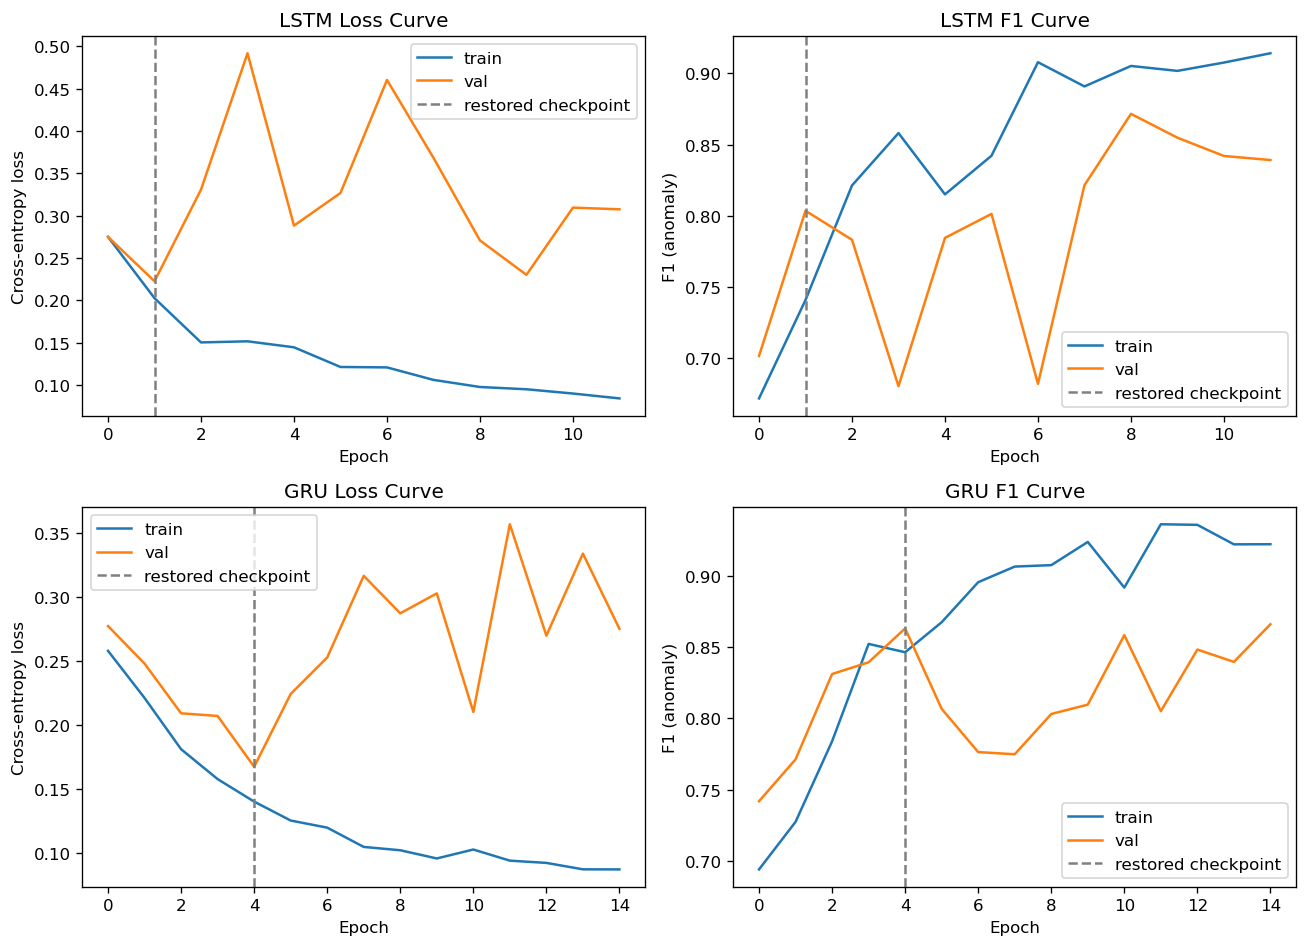

In [6]:

rnn_models, rnn_histories, rnn_epochs = {}, {}, {}
for rtype in ['lstm', 'gru']:
    model, history, n_ep = train_rnn(rtype, Xw50_tr, y50_tr, Xw50_va, y50_va, DEVICE)
    rnn_models[rtype] = model
    rnn_histories[rtype] = history
    rnn_epochs[rtype] = n_ep
    be = history['best_epoch']
    print(f'{rtype.upper():5s} trained for {n_ep} epochs (early stopping, patience=10); '
          f'best checkpoint restored from epoch {be + 1}  '
          f'(train F1={history["train_f1"][be]:.4f}, val F1={history["val_f1"][be]:.4f})')

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for i, rtype in enumerate(['lstm', 'gru']):
    h = rnn_histories[rtype]
    be = h['best_epoch']
    axes[i, 0].plot(h['train_loss'], label='train')
    axes[i, 0].plot(h['val_loss'], label='val')
    axes[i, 0].axvline(be, color='gray', linestyle='--', label='restored checkpoint')
    axes[i, 0].set(xlabel='Epoch', ylabel='Cross-entropy loss', title=f'{rtype.upper()} Loss Curve')
    axes[i, 0].legend()
    axes[i, 1].plot(h['train_f1'], label='train')
    axes[i, 1].plot(h['val_f1'], label='val')
    axes[i, 1].axvline(be, color='gray', linestyle='--', label='restored checkpoint')
    axes[i, 1].set(xlabel='Epoch', ylabel='F1 (anomaly)', title=f'{rtype.upper()} F1 Curve')
    axes[i, 1].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'rnn_learning_curves.png')
plt.show()


### 4.2 Evaluation — LSTM & GRU

Val-tuned decision threshold.


[LSTM] Val-tuned decision threshold: 0.49  (val F1 0.8067 vs 0.8034 at default t=0.50)
-- Train --
              precision    recall  f1-score   support

      Normal     0.9934    0.8707    0.9280      8134
     Anomaly     0.5962    0.9706    0.7386      1600

    accuracy                         0.8871      9734
   macro avg     0.7948    0.9206    0.8333      9734
weighted avg     0.9281    0.8871    0.8969      9734

AUC-ROC: 0.9731
-- Validation --
              precision    recall  f1-score   support

      Normal     0.9896    0.9232    0.9552      1861
     Anomaly     0.7015    0.9492    0.8067       354

    accuracy                         0.9273      2215
   macro avg     0.8455    0.9362    0.8810      2215
weighted avg     0.9436    0.9273    0.9315      2215

AUC-ROC: 0.9717
-- Test --
              precision    recall  f1-score   support

      Normal     0.9443    0.9230    0.9335      1597
     Anomaly     0.6382    0.7138    0.6739       304

    accuracy          

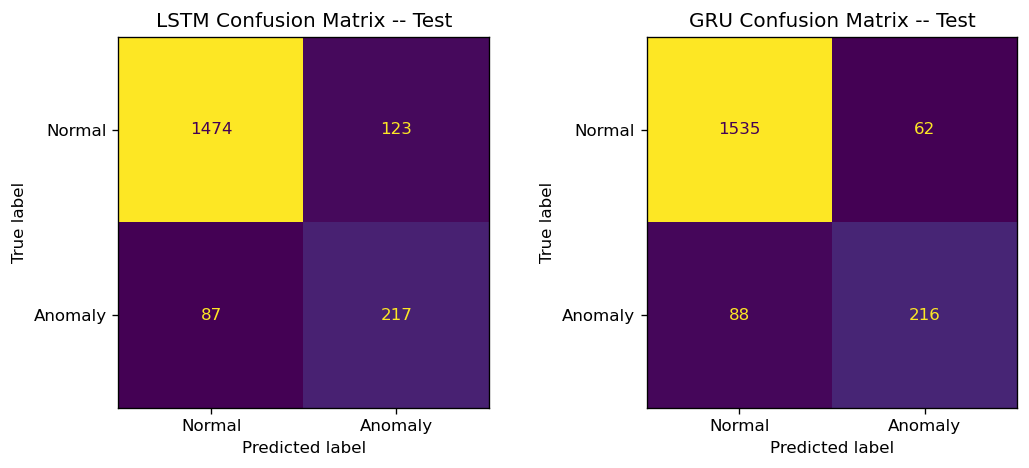

In [7]:

rnn_results = {}
for rtype in ['lstm', 'gru']:
    model = rnn_models[rtype]
    proba_tr = predict_proba(model, Xw50_tr, DEVICE)
    proba_va = predict_proba(model, Xw50_va, DEVICE)
    proba_te = predict_proba(model, Xw50_te, DEVICE)

    thr, val_f1_tuned = tune_threshold(y50_va, proba_va)
    val_f1_default = f1_score(y50_va, (proba_va >= 0.5).astype(int))
    print(f'\n[{rtype.upper()}] Val-tuned decision threshold: {thr:.2f}  '
          f'(val F1 {val_f1_tuned:.4f} vs {val_f1_default:.4f} at default t=0.50)')

    pred_te = (proba_te >= thr).astype(int)
    for y_true, proba, split_name in [(y50_tr, proba_tr, 'Train'), (y50_va, proba_va, 'Validation'),
                                       (y50_te, proba_te, 'Test')]:
        pred = (proba >= thr).astype(int)
        print(f'-- {split_name} --')
        print(classification_report(y_true, pred, target_names=['Normal', 'Anomaly'], digits=4))
        print(f'AUC-ROC: {roc_auc_score(y_true, proba):.4f}')

    test_f1 = f1_score(y50_te, pred_te)
    test_f1_default = f1_score(y50_te, (proba_te >= 0.5).astype(int))
    tn, fp, fn, tp = confusion_matrix(y50_te, pred_te).ravel()
    print(f'Test F1 -- val-tuned threshold (t={thr:.2f}): {test_f1:.4f}  |  default t=0.50: {test_f1_default:.4f}')
    print(f'Test confusion matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}')

    rnn_results[rtype] = dict(threshold=thr, test_f1=test_f1, test_f1_default=test_f1_default,
                               test_auc=roc_auc_score(y50_te, proba_te), tn=tn, fp=fp, fn=fn, tp=tp,
                               proba_te=proba_te, pred_te=pred_te)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, rtype in zip(axes, ['lstm', 'gru']):
    r = rnn_results[rtype]
    ConfusionMatrixDisplay(confusion_matrix(y50_te, r['pred_te']),
                           display_labels=['Normal', 'Anomaly']).plot(ax=ax, colorbar=False)
    ax.set_title(f'{rtype.upper()} Confusion Matrix -- Test')
plt.tight_layout()
plt.savefig(IMG_DIR / 'rnn_confusion_matrices.png')
plt.show()


### 4.3 Latency — LSTM & GRU (Canonical, w=50)

In [8]:

x_single_50 = torch.tensor(Xw50_te[0:1], dtype=torch.float32)
x_batch_1k_50 = torch.tensor(
    Xw50_te[:1000] if len(Xw50_te) >= 1000 else np.tile(Xw50_te, (1000 // len(Xw50_te) + 1, 1, 1))[:1000],
    dtype=torch.float32)

rnn_latency = {}
for rtype in ['lstm', 'gru']:
    single_ms, batch_ms = measure_latency(rnn_models[rtype], x_single_50, x_batch_1k_50, N_REPS)
    rnn_latency[rtype] = single_ms
    verdict = 'PASS' if single_ms <= CONSTRAINT_MS else 'FAIL'
    print(f'{rtype.upper():5s} single-sample inference (CPU): {single_ms:.4f} ms  |  '
          f'1,000-sample batch: {batch_ms:.4f} ms  |  Aido Rover constraint (<=100 ms): {verdict}')


LSTM  single-sample inference (CPU): 1.2573 ms  |  1,000-sample batch: 15.1702 ms  |  Aido Rover constraint (<=100 ms): PASS


GRU   single-sample inference (CPU): 0.6213 ms  |  1,000-sample batch: 19.8280 ms  |  Aido Rover constraint (<=100 ms): PASS


## 5. Transformer Encoder

`Linear(11→64) → sinusoidal PE → nn.TransformerEncoder(2 layers, 4 heads, d_model=64, ff=128, dropout=0.1) → mean-pool → Linear(64→2)`.

Choices in one line each (full justification: report §2): d_model=64 capacity-matched to the RNNs/MLP; 4 heads = 16 dims/head; 2 layers for ~9.7K windows; ff = 2×d_model convention; dropout 0.1 — attention already mixes across all positions; sinusoidal PE — fixed window, a learned table buys nothing; mean-pool over CLS — no pretraining to make a CLS token pay; no causal mask — the buffer is complete at classification time. Fixed config, trained once (no architecture sweep).

In [9]:

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=50):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(self, input_size=11, d_model=64, nhead=4, num_layers=2, dim_feedforward=128,
                 dropout=0.1, max_len=50):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(d_model, 2)
        self.d_model = d_model

    def forward(self, x):
        h = self.pos_enc(self.input_proj(x))
        h = self.transformer_encoder(h)
        pooled = h.mean(dim=1)          # many-to-one: mean-pool over the window
        return self.fc(self.dropout(pooled))


def train_transformer(X_tr, y_tr, X_va, y_va, device, max_epochs=100, patience=10, seed=SEED, max_len=50):
    torch.manual_seed(seed)
    model = TransformerClassifier(input_size=X_tr.shape[-1], max_len=max_len).to(device)
    cw = class_weight_tensor(y_tr, device)
    criterion = nn.CrossEntropyLoss(weight=cw)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = make_loader(X_tr, y_tr)
    model, history, n_ep = train_with_early_stopping(model, loader, X_tr, y_tr, X_va, y_va, criterion,
                                                      optimizer, device, max_epochs=max_epochs, patience=patience)
    return model, history, n_ep


### 5.1 Canonical-Fold Training — Transformer

Transformer trained for 28 epochs (early stopping, patience=10); best checkpoint restored from epoch 18  (train F1=0.9323, val F1=0.8895)


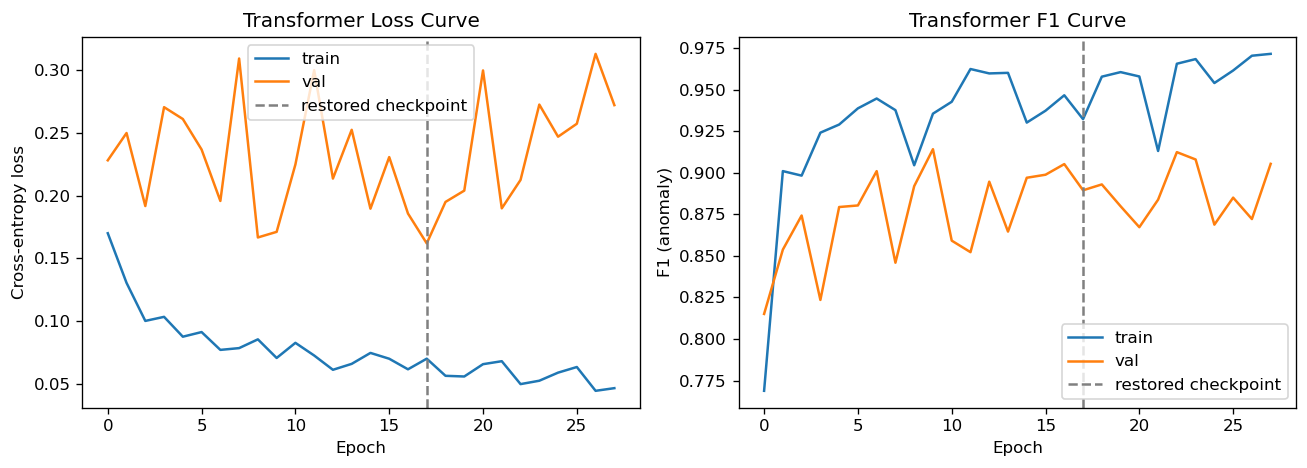

In [10]:

transformer_model, transformer_history, transformer_epochs = train_transformer(
    Xw50_tr, y50_tr, Xw50_va, y50_va, DEVICE)
be = transformer_history['best_epoch']
print(f'Transformer trained for {transformer_epochs} epochs (early stopping, patience=10); '
      f'best checkpoint restored from epoch {be + 1}  '
      f'(train F1={transformer_history["train_f1"][be]:.4f}, val F1={transformer_history["val_f1"][be]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(transformer_history['train_loss'], label='train')
axes[0].plot(transformer_history['val_loss'], label='val')
axes[0].axvline(be, color='gray', linestyle='--', label='restored checkpoint')
axes[0].set(xlabel='Epoch', ylabel='Cross-entropy loss', title='Transformer Loss Curve')
axes[0].legend()
axes[1].plot(transformer_history['train_f1'], label='train')
axes[1].plot(transformer_history['val_f1'], label='val')
axes[1].axvline(be, color='gray', linestyle='--', label='restored checkpoint')
axes[1].set(xlabel='Epoch', ylabel='F1 (anomaly)', title='Transformer F1 Curve')
axes[1].legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'transformer_learning_curves.png')
plt.show()


### 5.2 Evaluation — Transformer

Val-tuned decision threshold: 0.87  (val F1 0.9249 vs 0.8895 at default t=0.50)
-- Train --
              precision    recall  f1-score   support

      Normal     0.9942    0.9871    0.9906      8134
     Anomaly     0.9367    0.9706    0.9533      1600

    accuracy                         0.9844      9734
   macro avg     0.9654    0.9789    0.9720      9734
weighted avg     0.9847    0.9844    0.9845      9734

AUC-ROC: 0.9962
-- Validation --
              precision    recall  f1-score   support

      Normal     0.9819    0.9903    0.9861      1861
     Anomaly     0.9467    0.9040    0.9249       354

    accuracy                         0.9765      2215
   macro avg     0.9643    0.9471    0.9555      2215
weighted avg     0.9763    0.9765    0.9763      2215

AUC-ROC: 0.9850
-- Test --
              precision    recall  f1-score   support

      Normal     0.9385    0.9937    0.9653      1597
     Anomaly     0.9524    0.6579    0.7782       304

    accuracy                  

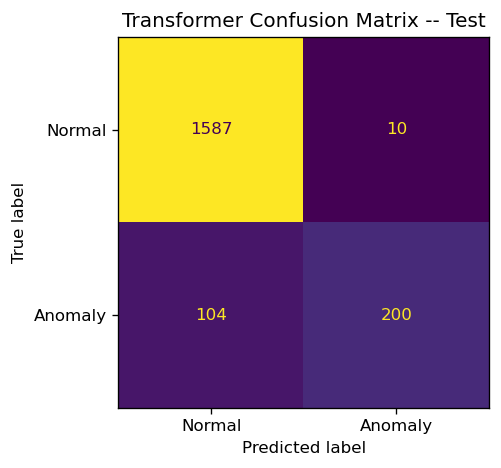

In [11]:

proba_tr_t = predict_proba(transformer_model, Xw50_tr, DEVICE)
proba_va_t = predict_proba(transformer_model, Xw50_va, DEVICE)
proba_te_t = predict_proba(transformer_model, Xw50_te, DEVICE)

thr_t, val_f1_tuned_t = tune_threshold(y50_va, proba_va_t)
val_f1_default_t = f1_score(y50_va, (proba_va_t >= 0.5).astype(int))
print(f'Val-tuned decision threshold: {thr_t:.2f}  (val F1 {val_f1_tuned_t:.4f} vs {val_f1_default_t:.4f} at default t=0.50)')

pred_te_t = (proba_te_t >= thr_t).astype(int)
for y_true, proba, split_name in [(y50_tr, proba_tr_t, 'Train'), (y50_va, proba_va_t, 'Validation'),
                                   (y50_te, proba_te_t, 'Test')]:
    pred = (proba >= thr_t).astype(int)
    print(f'-- {split_name} --')
    print(classification_report(y_true, pred, target_names=['Normal', 'Anomaly'], digits=4))
    print(f'AUC-ROC: {roc_auc_score(y_true, proba):.4f}')

transformer_test_f1 = f1_score(y50_te, pred_te_t)
transformer_test_f1_default = f1_score(y50_te, (proba_te_t >= 0.5).astype(int))
transformer_test_auc = roc_auc_score(y50_te, proba_te_t)
tn_t, fp_t, fn_t, tp_t = confusion_matrix(y50_te, pred_te_t).ravel()
print(f'Test F1 -- val-tuned threshold (t={thr_t:.2f}): {transformer_test_f1:.4f}  |  default t=0.50: {transformer_test_f1_default:.4f}')
print(f'Test confusion matrix: TN={tn_t}, FP={fp_t}, FN={fn_t}, TP={tp_t}')

fig, ax = plt.subplots(1, 1, figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y50_te, pred_te_t),
                       display_labels=['Normal', 'Anomaly']).plot(ax=ax, colorbar=False)
ax.set_title('Transformer Confusion Matrix -- Test')
plt.tight_layout()
plt.savefig(IMG_DIR / 'transformer_confusion_matrix.png')
plt.show()


### 5.3 Latency — Transformer (Canonical, w=50)

In [12]:

transformer_single_ms, transformer_batch_ms = measure_latency(transformer_model, x_single_50, x_batch_1k_50, N_REPS)
transformer_verdict = 'PASS' if transformer_single_ms <= CONSTRAINT_MS else 'FAIL'
print(f'Transformer single-sample inference (CPU): {transformer_single_ms:.4f} ms  |  '
      f'1,000-sample batch: {transformer_batch_ms:.4f} ms  |  '
      f'Aido Rover constraint (<=100 ms): {transformer_verdict}')


Transformer single-sample inference (CPU): 0.4392 ms  |  1,000-sample batch: 55.5396 ms  |  Aido Rover constraint (<=100 ms): PASS


## 6. Head-to-Head Comparison (Identical Data, Seeds, Protocol)

### 6.1 Convergence Speed

In [13]:

convergence_rows = []
for name, hist, n_ep in [('LSTM', rnn_histories['lstm'], rnn_epochs['lstm']),
                          ('GRU', rnn_histories['gru'], rnn_epochs['gru']),
                          ('Transformer', transformer_history, transformer_epochs)]:
    convergence_rows.append({'model': name, 'epochs_run': n_ep,
                              'best_epoch': hist['best_epoch'] + 1,
                              'best_val_loss': round(hist['val_loss'][hist['best_epoch']], 4)})
convergence_df = pd.DataFrame(convergence_rows)
print(convergence_df.to_string(index=False))


      model  epochs_run  best_epoch  best_val_loss
       LSTM          12           2         0.2227
        GRU          15           5         0.1674
Transformer          28          18         0.1618


### 6.2 7-Fold Block Rotation

Each model's fixed, already-justified configuration (§4, §5) is retrained from scratch across all 7
canonical fold rotations (`test=fold k`, `val=fold (k+1) mod 7`, `train`=the remaining 5 folds), with
per-channel standardization refit on that rotation's own train fold only (no leakage) and the decision
threshold re-tuned on that rotation's val fold, at w=50.

In [14]:

def rotate_seq(model_type, Xw_raw_all, y_all, fold_all, device):
    f1_default_folds, f1_tuned_folds, auc_folds = [], [], []
    for k in range(7):
        te_mask = fold_all == k
        va_mask = fold_all == (k + 1) % 7
        tr_mask = ~(te_mask | va_mask)

        ch_mean_k, ch_std_k = standardize_channels(Xw_raw_all[tr_mask])
        X_tr_k = apply_standardize(Xw_raw_all[tr_mask], ch_mean_k, ch_std_k)
        X_va_k = apply_standardize(Xw_raw_all[va_mask], ch_mean_k, ch_std_k)
        X_te_k = apply_standardize(Xw_raw_all[te_mask], ch_mean_k, ch_std_k)
        y_tr_k = y_all[tr_mask].astype(np.int64)
        y_va_k = y_all[va_mask].astype(np.int64)
        y_te_k = y_all[te_mask].astype(np.int64)

        if model_type == 'transformer':
            model, _, _ = train_transformer(X_tr_k, y_tr_k, X_va_k, y_va_k, device, max_len=Xw_raw_all.shape[1])
        else:
            model, _, _ = train_rnn(model_type, X_tr_k, y_tr_k, X_va_k, y_va_k, device)

        p_va = predict_proba(model, X_va_k, device)
        p_te = predict_proba(model, X_te_k, device)
        t_k, _ = tune_threshold(y_va_k, p_va)
        f1_default_folds.append(f1_score(y_te_k, (p_te >= 0.5).astype(int)))
        f1_tuned_folds.append(f1_score(y_te_k, (p_te >= t_k).astype(int)))
        auc_folds.append(roc_auc_score(y_te_k, p_te))
        print(f'  [{model_type:11s}] fold {k}: F1@0.5={f1_default_folds[-1]:.4f}  '
              f'F1@tuned(t={t_k:.2f})={f1_tuned_folds[-1]:.4f}  AUC={auc_folds[-1]:.4f}')
    return np.array(f1_default_folds), np.array(f1_tuned_folds), np.array(auc_folds)


seq_7fold_results = {}
for model_type in ['lstm', 'gru', 'transformer']:
    print(f'\n=== 7-fold rotation: {model_type} ===')
    f1_def, f1_tun, aucs = rotate_seq(model_type, Xw_all[50], y_all, fold_id_all, DEVICE)
    seq_7fold_results[model_type] = {'f1_default': f1_def, 'f1_tuned': f1_tun, 'auc': aucs}
    print(f'[{model_type:11s}] 7-fold F1@0.5   : mean={f1_def.mean():.4f} +/- {f1_def.std():.4f}')
    print(f'[{model_type:11s}] 7-fold F1@tuned : mean={f1_tun.mean():.4f} +/- {f1_tun.std():.4f}')
    print(f'[{model_type:11s}] 7-fold AUC      : mean={aucs.mean():.4f} +/- {aucs.std():.4f}')



=== 7-fold rotation: lstm ===


  [lstm       ] fold 0: F1@0.5=0.6881  F1@tuned(t=0.92)=0.7965  AUC=0.9806


  [lstm       ] fold 1: F1@0.5=0.7843  F1@tuned(t=0.12)=0.6256  AUC=0.9693


  [lstm       ] fold 2: F1@0.5=0.6205  F1@tuned(t=0.46)=0.6111  AUC=0.9573


  [lstm       ] fold 3: F1@0.5=0.4749  F1@tuned(t=0.86)=0.3863  AUC=0.9703


...

  [transformer] fold 2: F1@0.5=0.7932  F1@tuned(t=0.35)=0.8007  AUC=0.9778


  [transformer] fold 3: F1@0.5=0.6838  F1@tuned(t=0.47)=0.6902  AUC=0.9785


  [transformer] fold 4: F1@0.5=0.8321  F1@tuned(t=0.93)=0.8870  AUC=0.9855


  [transformer] fold 5: F1@0.5=0.7891  F1@tuned(t=0.94)=0.8608  AUC=0.9841


  [transformer] fold 6: F1@0.5=0.9091  F1@tuned(t=0.95)=0.8511  AUC=0.9905
[transformer] 7-fold F1@0.5   : mean=0.8138 +/- 0.0746
[transformer] 7-fold F1@tuned : mean=0.8289 +/- 0.0688
[transformer] 7-fold AUC      : mean=0.9822 +/- 0.0045


In [15]:
# baseline rows from the ledger + the three freshly computed sequence models -- any LSTM/GRU/Transformer
# rows already in the file (from a previous run of this notebook) are excluded so each model appears once
ledger_now = pd.read_csv(ledger_path)
compare_rows = []
prior = ledger_now[(ledger_now['task'] == 'rover_anomaly')
                   & (~ledger_now['model'].isin(['LSTM', 'GRU', 'Transformer']))]
for _, row in prior.iterrows():
    compare_rows.append({'model': row['model'], 'latency_ms': row['latency_ms'],
                          'f1_test': row['f1_test'], 'f1_test_std': row['f1_test_std'],
                          'auc_test': row['auc_test'], 'auc_test_std': row['auc_test_std']})
for model_type in ['lstm', 'gru', 'transformer']:
    r = seq_7fold_results[model_type]
    compare_rows.append({'model': model_type.upper() if model_type != 'transformer' else 'Transformer',
                          'latency_ms': {'lstm': rnn_latency['lstm'], 'gru': rnn_latency['gru'],
                                         'transformer': transformer_single_ms}[model_type],
                          'f1_test': round(r['f1_tuned'].mean(), 4), 'f1_test_std': round(r['f1_tuned'].std(), 4),
                          'auc_test': round(r['auc'].mean(), 4), 'auc_test_std': round(r['auc'].std(), 4)})
compare_df = pd.DataFrame(compare_rows)
print(compare_df.to_string(index=False))

       model  latency_ms  f1_test  f1_test_std  auc_test  auc_test_std
RandomForest    7.856000   0.7492       0.0481    0.9595        0.0092
         MLP    0.135100   0.7936       0.0472    0.9786        0.0112
      1D-CNN    0.151600   0.7307       0.1147    0.9648        0.0221
        LSTM    1.257308   0.7038       0.1590    0.9694        0.0137
         GRU    0.621338   0.7468       0.0818    0.9747        0.0062
 Transformer    0.439245   0.8289       0.0688    0.9822        0.0045


In [16]:

# per-axis winners, computed off the comparison table above
seq_names = {'LSTM', 'GRU', 'Transformer'}
best_f1 = compare_df.loc[compare_df['f1_test'].idxmax()]
best_auc = compare_df.loc[compare_df['auc_test'].idxmax()]
most_stable = compare_df.loc[compare_df['f1_test_std'].idxmin()]
least_stable = compare_df.loc[compare_df['f1_test_std'].idxmax()]
lowest_lat = compare_df.loc[compare_df['latency_ms'].idxmin()]
seq_only = compare_df[compare_df['model'].isin(seq_names)]
seq_best_f1 = seq_only.loc[seq_only['f1_test'].idxmax()]
seq_low_lat = seq_only.loc[seq_only['latency_ms'].idxmin()]

print('Per-axis winners (whole ledger unless noted):')
print(f'  Detection F1   : {best_f1["model"]:12s} (F1={best_f1["f1_test"]:.4f} +/- {best_f1["f1_test_std"]:.4f})')
print(f'  Discrimination : {best_auc["model"]:12s} (AUC={best_auc["auc_test"]:.4f})')
print(f'  Fold stability : {most_stable["model"]:12s} (F1 std={most_stable["f1_test_std"]:.4f}, lowest)')
print(f'  Least stable   : {least_stable["model"]:12s} (F1 std={least_stable["f1_test_std"]:.4f}, highest)')
print(f'  Lowest latency : {lowest_lat["model"]:12s} ({lowest_lat["latency_ms"]:.4f} ms)')
print(f'  Sequence-only  -> best F1: {seq_best_f1["model"]} ({seq_best_f1["f1_test"]:.4f}); '
      f'fastest: {seq_low_lat["model"]} ({seq_low_lat["latency_ms"]:.4f} ms)')
all_pass = (compare_df['latency_ms'] <= CONSTRAINT_MS).all()
print(f'  100 ms gate    : {"all models PASS" if all_pass else "SOME MODELS FAIL"}')


Per-axis winners (whole ledger unless noted):
  Detection F1   : Transformer  (F1=0.8289 +/- 0.0688)
  Discrimination : Transformer  (AUC=0.9822)
  Fold stability : MLP          (F1 std=0.0472, lowest)
  Least stable   : LSTM         (F1 std=0.1590, highest)
  Lowest latency : MLP          (0.1351 ms)
  Sequence-only  -> best F1: Transformer (0.8289); fastest: Transformer (0.4392 ms)
  100 ms gate    : all models PASS


**Per-axis winners** (full analysis: report §3): **highest single-number F1/AUC — Transformer** (tightest fold-to-fold AUC spread too) — but §6.5 shows this is a near-tie: not significant vs the MLP and gone at matched parameters, so it is a capacity result; what attention uniquely adds is fault localisation (§7), not per-parameter detection. **Stability — GRU over LSTM decisively** (LSTM ±0.159 = worst in the ledger; a threshold-calibration failure — its AUC stays high). **Latency — all three clear the gate by orders of magnitude** (§6.4). **Data efficiency — Transformer leads at every fraction**; no model gains significantly from 50%→100% (§6.3).

### 6.5 Capacity Control — Param-Matched Transformer + Paired Significance

The §6.2 head-to-head matches **width** (hidden / d_model = 64), not **parameters**: a 2-layer attention encoder carries ~4.5× the weights of a same-width RNN (67.8K vs 14.9K/19.8K), so the comparison confounds architecture with capacity. A param-matched **Transformer-S** (d_model=32, ff=64, 17.5K params — GRU/LSTM scale) isolates the two. Paired per-fold t-tests (7 folds as paired samples) then convert the mean-F1 gaps in §6.2 into significance calls, so the ledger's single-number winner is not read as a significant one without a test.

In [17]:
from scipy import stats

def _pcount(m):
    return sum(p.numel() for p in m.parameters())

param_counts = {'LSTM': _pcount(RNNClassifier(rnn_type='lstm')),
                'GRU': _pcount(RNNClassifier(rnn_type='gru')),
                'Transformer(d=64)': _pcount(TransformerClassifier(d_model=64, dim_feedforward=128)),
                'Transformer-S(d=32)': _pcount(TransformerClassifier(d_model=32, dim_feedforward=64))}
print('Parameter counts:', '  '.join(f'{k}={v:,}' for k, v in param_counts.items()))


def train_transformer_s(X_tr, y_tr, X_va, y_va, device, seed=SEED, max_len=50):
    torch.manual_seed(seed)
    model = TransformerClassifier(input_size=X_tr.shape[-1], d_model=32, nhead=4,
                                  dim_feedforward=64, max_len=max_len).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight_tensor(y_tr, device))
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model, _, _ = train_with_early_stopping(model, make_loader(X_tr, y_tr), X_tr, y_tr, X_va, y_va,
                                            criterion, optimizer, device)
    return model

# 7-fold rotation, identical partition/standardization/threshold protocol as 6.2
ts_f1, ts_auc = [], []
for k in range(7):
    te = fold_id_all == k; va = fold_id_all == (k + 1) % 7; tr = ~(te | va)
    cm, cs = standardize_channels(Xw_all[50][tr])
    Xt = apply_standardize(Xw_all[50][tr], cm, cs); Xv = apply_standardize(Xw_all[50][va], cm, cs)
    Xe = apply_standardize(Xw_all[50][te], cm, cs)
    m = train_transformer_s(Xt, y_all[tr].astype(np.int64), Xv, y_all[va].astype(np.int64), DEVICE,
                            max_len=Xw_all[50].shape[1])
    pv = predict_proba(m, Xv, DEVICE); pe = predict_proba(m, Xe, DEVICE)
    t_k, _ = tune_threshold(y_all[va].astype(np.int64), pv)
    ts_f1.append(f1_score(y_all[te].astype(np.int64), (pe >= t_k).astype(int)))
    ts_auc.append(roc_auc_score(y_all[te].astype(np.int64), pe))
ts_f1, ts_auc = np.array(ts_f1), np.array(ts_auc)
print(f'Transformer-S (d=32, {param_counts["Transformer-S(d=32)"]:,} params) 7-fold F1: '
      f'{ts_f1.mean():.4f} +/- {ts_f1.std():.4f}   AUC: {ts_auc.mean():.4f} +/- {ts_auc.std():.4f}')

# paired per-fold F1 tests -- MLP/RF/CNN folds from the ledger, sequence models from seq_7fold_results
_led = pd.read_csv(ledger_path).set_index('model')
_folds = {name: _led.loc[name, [f'fold_{k}' for k in range(7)]].astype(float).values
          for name in ['MLP', 'RandomForest', '1D-CNN']}
_folds['LSTM'] = seq_7fold_results['lstm']['f1_tuned']
_folds['GRU'] = seq_7fold_results['gru']['f1_tuned']
_folds['Transformer'] = seq_7fold_results['transformer']['f1_tuned']
_folds['Transformer-S'] = ts_f1

print('\nPaired per-fold F1 significance (7 folds):')
for a, b in [('Transformer', 'MLP'), ('Transformer', 'GRU'), ('Transformer', 'RandomForest'),
             ('Transformer-S', 'GRU'), ('Transformer-S', 'MLP')]:
    d = _folds[a] - _folds[b]
    t, pval = stats.ttest_rel(_folds[a], _folds[b])
    verdict = 'significant' if pval < 0.05 else 'NOT significant'
    print(f'  {a:13s} vs {b:12s}: mean dF1={d.mean():+.4f}  paired t={t:+.2f}  p={pval:.4f}  '
          f'({verdict})  worst-fold {a}={_folds[a].min():.3f} / {b}={_folds[b].min():.3f}')

Parameter counts: LSTM=19,842  GRU=14,914  Transformer(d=64)=67,842  Transformer-S(d=32)=17,538


Transformer-S (d=32, 17,538 params) 7-fold F1: 0.7604 +/- 0.0522   AUC: 0.9698 +/- 0.0138

Paired per-fold F1 significance (7 folds):
  Transformer   vs MLP         : mean dF1=+0.0353  paired t=+1.04  p=0.3363  (NOT significant)  worst-fold Transformer=0.690 / MLP=0.736
  Transformer   vs GRU         : mean dF1=+0.0821  paired t=+2.45  p=0.0498  (significant)  worst-fold Transformer=0.690 / GRU=0.602
  Transformer   vs RandomForest: mean dF1=+0.0797  paired t=+3.59  p=0.0115  (significant)  worst-fold Transformer=0.690 / RandomForest=0.697
  Transformer-S vs GRU         : mean dF1=+0.0136  paired t=+0.32  p=0.7564  (NOT significant)  worst-fold Transformer-S=0.683 / GRU=0.602
  Transformer-S vs MLP         : mean dF1=-0.0332  paired t=-1.10  p=0.3153  (NOT significant)  worst-fold Transformer-S=0.683 / MLP=0.736


**Reading (full analysis: report §3).** At matched width the Transformer leads, but the lead is inseparable from a 4.5× parameter budget: shrunk to 17.5K params (GRU/LSTM scale) its 7-fold F1 falls 0.829→**0.760** and it becomes statistically **indistinguishable from the GRU** (paired p=0.76) and trails the feature-engineered MLP. The paired tests also show the full Transformer's edge is **not significant vs MLP** (p=0.34; MLP even has the better worst fold, 0.736 vs 0.690), only borderline vs GRU (p=0.05) and significant vs RF (p=0.01). So the honest read of §6.2 is a large MLP/GRU/RF/Transformer-S near-tie with only the 67.8K-param Transformer poking above — detection quality does not separate the architectures at equal capacity; what the Transformer uniquely brings is fault **localisation** (§7), not per-parameter detection.

### 6.3 Data Efficiency (25% / 50% / 100% of Training Data)

Canonical fold only (compute-bounded), **3 training seeds per point** — a single run's F1 moves several points seed-to-seed here, indistinguishable from a data-scaling effect. Stratified subsample redrawn per seed; val/test fixed; standardization refit per fraction/seed (no leakage). Lines = 3-seed mean, bands = ±1 std.

seed=42  frac=0.25  n_train= 2434  [lstm       ] test F1=0.6575


seed=42  frac=0.25  n_train= 2434  [gru        ] test F1=0.7301


seed=42  frac=0.25  n_train= 2434  [transformer] test F1=0.7668


seed=42  frac=0.50  n_train= 4867  [lstm       ] test F1=0.7346


seed=42  frac=0.50  n_train= 4867  [gru        ] test F1=0.7267


...

seed=44  frac=0.50  n_train= 4867  [gru        ] test F1=0.7365


seed=44  frac=0.50  n_train= 4867  [transformer] test F1=0.8541


seed=44  frac=1.00  n_train= 9734  [lstm       ] test F1=0.7586


seed=44  frac=1.00  n_train= 9734  [gru        ] test F1=0.7141


seed=44  frac=1.00  n_train= 9734  [transformer] test F1=0.7349


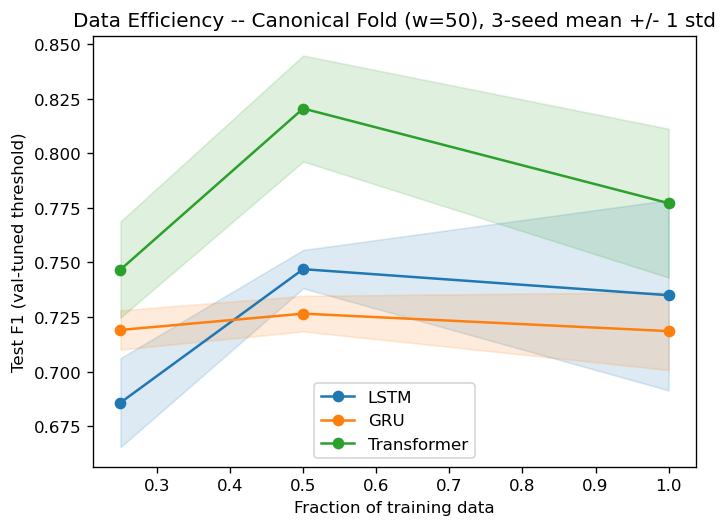


[lstm       ] 25%: 0.6858+/-0.0204  50%: 0.7469+/-0.0088  100%: 0.7350+/-0.0436
[gru        ] 25%: 0.7191+/-0.0090  50%: 0.7266+/-0.0081  100%: 0.7186+/-0.0178
[transformer] 25%: 0.7468+/-0.0220  50%: 0.8205+/-0.0242  100%: 0.7772+/-0.0341


In [18]:
def stratified_subsample(X, y, frac, seed=SEED):
    if frac >= 0.999:
        return X, y
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    n0 = max(1, int(round(len(idx0) * frac)))
    n1 = max(1, int(round(len(idx1) * frac)))
    sel0 = rng.choice(idx0, size=n0, replace=False)
    sel1 = rng.choice(idx1, size=n1, replace=False)
    sel = np.concatenate([sel0, sel1])
    rng.shuffle(sel)
    return X[sel], y[sel]


FRACTIONS = [0.25, 0.5, 1.0]
DE_SEEDS = [SEED, SEED + 1, SEED + 2]
data_efficiency = {mt: np.zeros((len(DE_SEEDS), len(FRACTIONS))) for mt in ['lstm', 'gru', 'transformer']}

for s_i, seed in enumerate(DE_SEEDS):
    for f_i, frac in enumerate(FRACTIONS):
        Xw50_tr_frac, y50_tr_frac = stratified_subsample(Xw[50]['train'], yw['train'], frac, seed=seed)
        ch_mean_f, ch_std_f = standardize_channels(Xw50_tr_frac)
        Xw50_tr_frac_n = apply_standardize(Xw50_tr_frac, ch_mean_f, ch_std_f)
        Xw50_va_frac_n = apply_standardize(Xw[50]['val'], ch_mean_f, ch_std_f)
        Xw50_te_frac_n = apply_standardize(Xw[50]['test'], ch_mean_f, ch_std_f)

        for model_type in ['lstm', 'gru', 'transformer']:
            if model_type == 'transformer':
                model, _, _ = train_transformer(Xw50_tr_frac_n, y50_tr_frac, Xw50_va_frac_n, yw['val'],
                                                DEVICE, seed=seed)
            else:
                model, _, _ = train_rnn(model_type, Xw50_tr_frac_n, y50_tr_frac, Xw50_va_frac_n, yw['val'],
                                        DEVICE, seed=seed)
            p_va = predict_proba(model, Xw50_va_frac_n, DEVICE)
            p_te = predict_proba(model, Xw50_te_frac_n, DEVICE)
            t_k, _ = tune_threshold(yw['val'], p_va)
            test_f1 = f1_score(yw['test'], (p_te >= t_k).astype(int))
            data_efficiency[model_type][s_i, f_i] = test_f1
            print(f'seed={seed}  frac={frac:.2f}  n_train={len(y50_tr_frac):5d}  '
                  f'[{model_type:11s}] test F1={test_f1:.4f}')

fig, ax = plt.subplots(figsize=(6, 4.5))
for model_type, label in [('lstm', 'LSTM'), ('gru', 'GRU'), ('transformer', 'Transformer')]:
    m = data_efficiency[model_type].mean(axis=0)
    s = data_efficiency[model_type].std(axis=0)
    line, = ax.plot(FRACTIONS, m, marker='o', label=label)
    ax.fill_between(FRACTIONS, m - s, m + s, alpha=0.15, color=line.get_color())
ax.set(xlabel='Fraction of training data', ylabel='Test F1 (val-tuned threshold)',
       title='Data Efficiency -- Canonical Fold (w=50), 3-seed mean +/- 1 std')
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'data_efficiency.png')
plt.show()

print()
for model_type in ['lstm', 'gru', 'transformer']:
    m = data_efficiency[model_type].mean(axis=0)
    s = data_efficiency[model_type].std(axis=0)
    print(f'[{model_type:11s}] ' + '  '.join(f'{f:.0%}: {mi:.4f}+/-{si:.4f}'
                                             for f, mi, si in zip(FRACTIONS, m, s)))

### 6.4 Latency vs. Window Size

Latency depends on the compute graph and input shape, not values — dummy `(1, w, 11)` tensors measure the wall-clock scaling per window length. Models were trained at w=50 only: this is a latency curve, not an accuracy claim at w=10/20.

[lstm       ] w=10: 0.1073 ms
[lstm       ] w=20: 0.1215 ms


[lstm       ] w=50: 0.1664 ms
[gru        ] w=10: 0.1521 ms
[gru        ] w=20: 0.2710 ms
[gru        ] w=50: 0.6225 ms
[transformer] w=10: 0.2336 ms


[transformer] w=20: 0.2557 ms


[transformer] w=50: 0.3096 ms


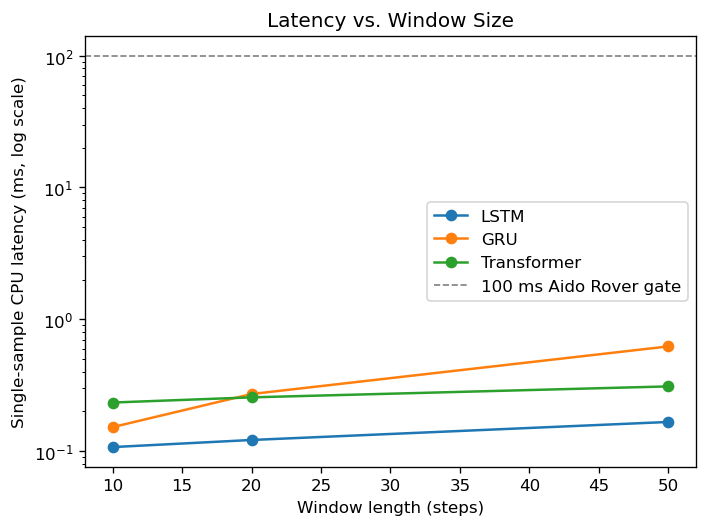


All three architectures clear the 100 ms gate by orders of magnitude at these window lengths (10-50 steps).
[lstm       ] fitted O(w) linear scaling -> 100 ms gate crossover: ~67,408 steps (6,741 s of buffer)
[gru        ] fitted O(w) linear scaling -> 100 ms gate crossover: ~8,507 steps (851 s of buffer)
[transformer] fitted O(w^2) quadratic scaling -> 100 ms gate crossover: overhead-dominated at w<=50; growth term below the noise floor, no crossover in range

The crossover windows above are extrapolations far beyond any window justified in §2 (max 50 steps / 5 s), and the CPU micro-latencies feeding them are noisy enough that the exact crossover shifts run to run -- the robust conclusion is only the order of magnitude: at this platform's sampling rate and fault-duration scale, detection quality (F1/AUC, §6.2-6.3), not inference latency, is the binding constraint for all three architectures.


In [19]:

latency_vs_window = {mt: {} for mt in ['lstm', 'gru', 'transformer']}
models_for_latency = {'lstm': rnn_models['lstm'], 'gru': rnn_models['gru'], 'transformer': transformer_model}

for model_type, model in models_for_latency.items():
    model_cpu = copy.deepcopy(model).to('cpu').eval()
    for w in WSIZES:
        x_dummy = torch.zeros(1, w, N_CHANNELS, dtype=torch.float32)
        with torch.no_grad():
            for _ in range(10):   # warm-up
                model_cpu(x_dummy)
            ms = timeit.timeit(lambda: model_cpu(x_dummy), number=N_REPS) / N_REPS * 1000
        latency_vs_window[model_type][w] = ms
        print(f'[{model_type:11s}] w={w:2d}: {ms:.4f} ms')

fig, ax = plt.subplots(figsize=(6, 4.5))
for model_type, label in [('lstm', 'LSTM'), ('gru', 'GRU'), ('transformer', 'Transformer')]:
    ax.plot(WSIZES, [latency_vs_window[model_type][w] for w in WSIZES], marker='o', label=label)
# log scale: the measured latencies (~0.1-0.7 ms) and the 100 ms gate are ~2-3 orders of magnitude
# apart, so a linear axis flattens all three model curves into an invisible band near zero -- log
# keeps everything on the one axis (never a second y-scale) while both the curve shapes and the
# gate stay legible.
ax.set_yscale('log')
ax.axhline(CONSTRAINT_MS, color='0.5', linestyle='--', linewidth=1, label='100 ms Aido Rover gate')
ax.set(xlabel='Window length (steps)', ylabel='Single-sample CPU latency (ms, log scale)',
       title='Latency vs. Window Size')
ax.legend()
plt.tight_layout()
plt.savefig(IMG_DIR / 'latency_vs_window.png')
plt.show()

print(f'\nAll three architectures clear the 100 ms gate by orders of magnitude at these window lengths '
      f'({WSIZES[0]}-{WSIZES[-1]} steps).')

# fit each model's measured (w, latency_ms) points to its theoretical scaling form, then solve for
# the window length at which the fitted curve would cross the 100 ms gate -- an extrapolation, not
# a measurement (no model here is trained or run at windows beyond w=50).
w_arr = np.array(WSIZES, dtype=float)
crossover_w = {}
for model_type, degree, label in [('lstm', 1, 'O(w) linear'), ('gru', 1, 'O(w) linear'),
                                   ('transformer', 2, 'O(w^2) quadratic')]:
    lat_arr = np.array([latency_vs_window[model_type][w] for w in WSIZES])
    coeffs = np.polyfit(w_arr, lat_arr, degree)   # highest-degree term first
    # solve coeffs(w) = CONSTRAINT_MS for the smallest positive real root beyond the fitted range
    poly = np.poly1d(coeffs) - CONSTRAINT_MS
    roots = [r.real for r in poly.roots if abs(r.imag) < 1e-6 and r.real > w_arr.max()]
    crossover_w[model_type] = min(roots) if roots else None
    if crossover_w[model_type]:
        root_str = f'~{crossover_w[model_type]:,.0f} steps ({crossover_w[model_type] / FS:,.0f} s of buffer)'
    else:
        # no crossover above the fitted range: at w<=50 the latency is dominated by fixed per-inference
        # overhead (model construction + the constant-cost linear/projection layers), so the growth term
        # (linear for RNNs, quadratic for attention) is still below that floor and cannot be pinned from
        # these measurements -- itself evidence that latency is nowhere near binding at these windows.
        root_str = 'overhead-dominated at w<=50; growth term below the noise floor, no crossover in range'
    print(f'[{model_type:11s}] fitted {label} scaling -> 100 ms gate crossover: {root_str}')

print('\nThe crossover windows above are extrapolations far beyond any window justified in §2 (max 50 steps '
      '/ 5 s), and the CPU micro-latencies feeding them are noisy enough that the exact crossover shifts '
      'run to run -- the robust conclusion is only the order of magnitude: at this platform\'s sampling rate '
      'and fault-duration scale, detection quality (F1/AUC, §6.2-6.3), not inference latency, is the binding '
      'constraint for all three architectures.')


**Same shape as the planning-horizon problem:** a longer window buys more context per decision but more compute per cycle (quadratic for attention). Here the crossover sits far outside any useful window; the quadrotor thesis planner lives on the binding side — its optimiser cost grows combinatorially with corridor length, so the horizon is truncated to stay real-time (quantified mapping: W04 report §7).

## 7. Attention Interpretability — Transformer vs. LSTM Hidden State vs. FFT Spectral View

One anomalous test window read through three lenses: Transformer attention (learned, over time), LSTM hidden-state norm (learned, causal), Week-2 FFT spectrum (analytical, over frequency). Attention weights are extracted post hoc by calling each trained layer's `self_attn` with `need_weights=True` (training itself used the fast path). Ground truth: every test window's per-step fault mask is reconstructed from the canonical split's anchor rows (window = rows `[i−50, i)` of `synthetic_rover_data.csv`) — one sample below, population-level in §7.1.

In [20]:

def get_attention_maps(model, x):
    """x: (1, seq, channels) tensor. Returns a list of length num_layers, each (nhead, seq, seq)."""
    model.eval()
    with torch.no_grad():
        h = model.pos_enc(model.input_proj(x))
        maps = []
        for layer in model.transformer_encoder.layers:
            _, attn_w = layer.self_attn(h, h, h, need_weights=True, average_attn_weights=False)
            maps.append(attn_w[0].cpu().numpy())   # (nhead, seq, seq)
            h = layer(h)                            # advance to the next layer's input
    return maps


# pick one anomalous test-window sample (w=50), the one the Transformer scores most confidently anomalous
anomaly_idx = np.where(y50_te == 1)[0]
sample_i = anomaly_idx[np.argmax(proba_te_t[anomaly_idx])]
x_sample = torch.tensor(Xw50_te[sample_i:sample_i + 1], dtype=torch.float32, device=DEVICE)
print(f'Selected test-window index {sample_i} (predicted anomaly probability={proba_te_t[sample_i]:.4f})')

attn_maps = get_attention_maps(transformer_model, x_sample)
print(f'Extracted {len(attn_maps)} layer(s) of attention weights, each shape {attn_maps[0].shape} (heads, seq, seq)')

# "attention received" per timestep: average over heads and over query positions (column mean) of the
# final layer -- how much total attention each key timestep receives from the rest of the window
final_layer_attn = attn_maps[-1]                       # (nhead, seq, seq)
attn_received = final_layer_attn.mean(axis=(0, 1))     # (seq,) -- avg over heads and queries

# LSTM hidden-state activation norm per timestep, same sample
lstm_model = rnn_models['lstm']
lstm_model.eval()
with torch.no_grad():
    _, hidden_seq = lstm_model(x_sample.to(DEVICE), return_hidden_seq=True)
hidden_norm = hidden_seq[0].norm(dim=-1).cpu().numpy()   # (seq,)

# Week-2 cross-channel view: inter_wheel_std over the same window, on the same time axis as the two
# learned views. It is one of the 11 input channels, not a post-hoc diagnostic. It is the right Week-2
# counterpart to attention here because the slip mechanism is cross-sectional, not spectral: the world
# core redraws the spiking wheel every step (`w = rng.integers(0, 4)` inside step()), so the fault shows
# up as cross-wheel spread at each instant, and no single torque channel carries a temporal pattern for
# a per-channel spectral view to pick up.
iws_idx = SENSOR_COLS.index('inter_wheel_std')
iws_window = Xw[50]['test'][sample_i, :, iws_idx]   # raw (unstandardized) channel values

# ground truth: reconstruct every test window's per-step fault mask from the canonical split --
# test window j covers rows [a_j - 50, a_j) of synthetic_rover_data.csv, its label is row a_j's
split_df = pd.read_csv(DATA_DIR / 'rover_stratified_block_split.csv')
test_anchor_rows = split_df.loc[(~split_df['purged']) & (split_df['split'] == 'test'), 'row_idx'].values
assert len(test_anchor_rows) == len(y50_te)
assert np.array_equal(lbl[test_anchor_rows], y50_te), 'anchor labels must reproduce the window labels'
fault_masks_te = np.stack([lbl[a - 50:a] for a in test_anchor_rows])   # (n_test, 50)

sample_mask = fault_masks_te[sample_i]
if sample_mask.any():
    lo, hi = np.where(sample_mask == 1)[0][[0, -1]]
    print(f'Selected window ground truth: {int(sample_mask.sum())}/50 in-window fault steps '
          f'(timesteps {lo}-{hi} of the buffer)')
    m = sample_mask == 1
    print(f'inter_wheel_std: {iws_window[~m].mean():.2f} +/- {iws_window[~m].std():.2f} Nm on normal '
          f'steps vs {iws_window[m].mean():.2f} +/- {iws_window[m].std():.2f} Nm on fault steps '
          f'({iws_window[m].mean() / iws_window[~m].mean():.1f}x)')
else:
    print('Selected window ground truth: 0/50 in-window fault steps (fault onset at the anchor step itself)')


Selected test-window index 842 (predicted anomaly probability=0.9984)
Extracted 2 layer(s) of attention weights, each shape (4, 50, 50) (heads, seq, seq)
Selected window ground truth: 8/50 in-window fault steps (timesteps 42-49 of the buffer)
inter_wheel_std: 0.27 +/- 0.12 Nm on normal steps vs 1.40 +/- 0.08 Nm on fault steps (5.1x)


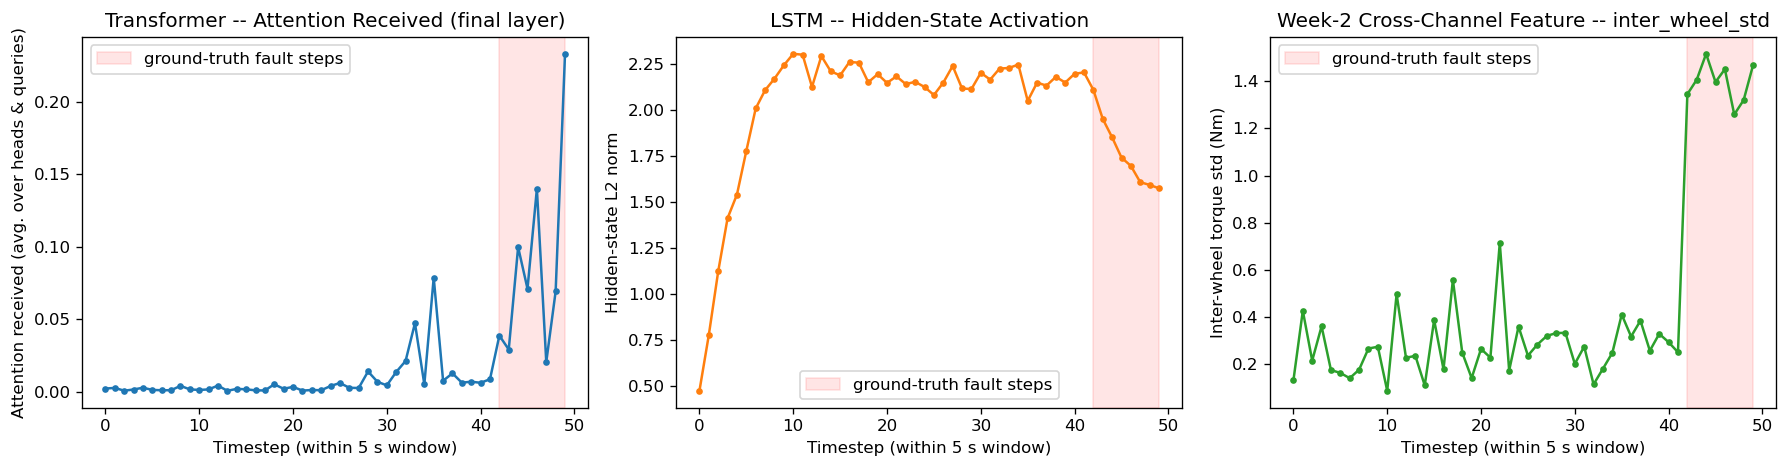

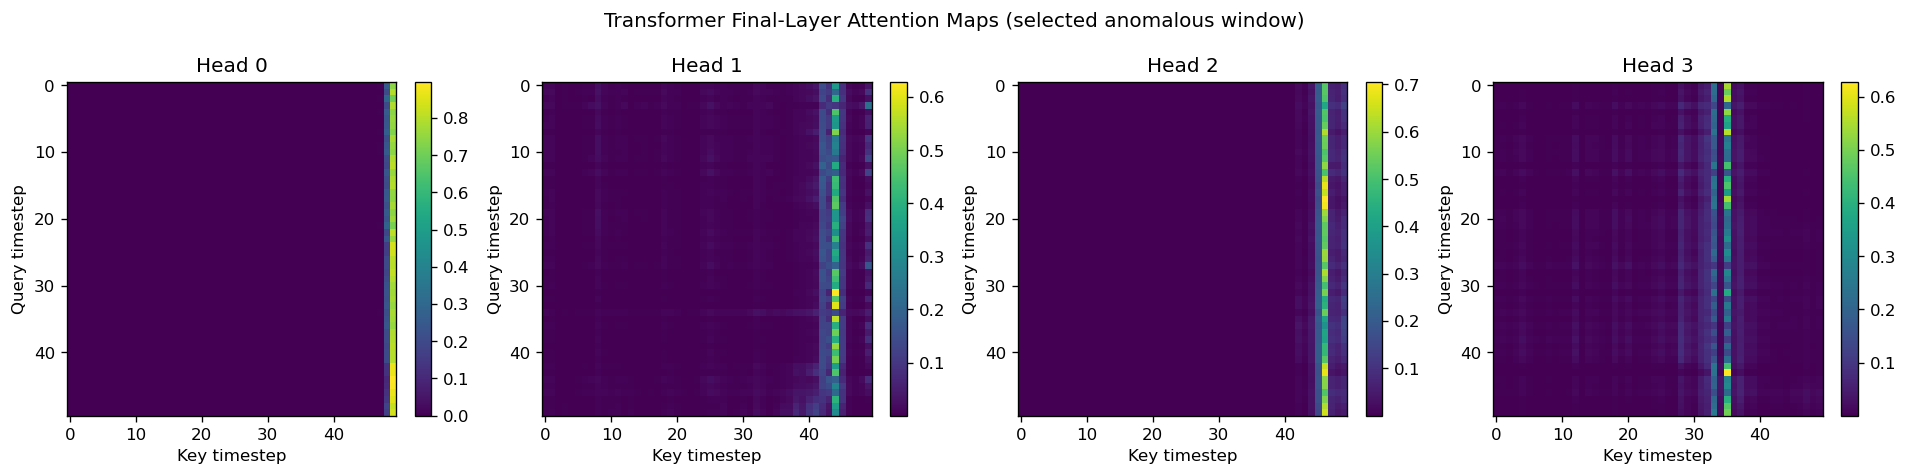

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(attn_received, marker='.')
axes[0].set(xlabel='Timestep (within 5 s window)', ylabel='Attention received (avg. over heads & queries)',
            title='Transformer -- Attention Received (final layer)')

axes[1].plot(hidden_norm, marker='.', color='tab:orange')
axes[1].set(xlabel='Timestep (within 5 s window)', ylabel='Hidden-state L2 norm', title='LSTM -- Hidden-State Activation')

axes[2].plot(iws_window, marker='.', color='tab:green')
axes[2].set(xlabel='Timestep (within 5 s window)', ylabel='Inter-wheel torque std (Nm)',
            title='Week-2 Cross-Channel Feature -- inter_wheel_std')

for ax in axes:   # shade the ground-truth fault steps behind all three views
    ylim = ax.get_ylim()
    ax.fill_between(np.arange(50), ylim[0], ylim[1], where=sample_mask == 1,
                    color='red', alpha=0.10, label='ground-truth fault steps')
    ax.set_ylim(ylim)
    ax.legend()

plt.tight_layout()
plt.savefig(IMG_DIR / 'attention_vs_hidden_vs_crosschannel.png')
plt.show()

# supplementary: per-head attention heatmaps, final layer
n_heads = final_layer_attn.shape[0]
fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
for head_i in range(n_heads):
    im = axes[head_i].imshow(final_layer_attn[head_i], cmap='viridis', aspect='auto')
    axes[head_i].set(xlabel='Key timestep', ylabel='Query timestep', title=f'Head {head_i}')
    plt.colorbar(im, ax=axes[head_i], fraction=0.046)
plt.suptitle('Transformer Final-Layer Attention Maps (selected anomalous window)')
plt.tight_layout()
plt.savefig(IMG_DIR / 'attention_heatmaps_per_head.png')
plt.show()


### 7.1 Quantitative Alignment — Learned Focus vs. Ground-Truth Fault Steps

Per-window **selectivity ratio** = mean attention received on fault steps / on normal steps (LSTM analogue: per-step |Δ hidden-norm|), over every anomalous test window holding both step types; >1 = focus on the true fault span without per-step labels. Detections are then stratified by in-window fault coverage and by fault-run length (type proxy: slip TTL 10–40 steps, stuck 30–80).

In [22]:
# batched attention-received (final layer, head-averaged then query-averaged) for all test windows
def batched_attn_received(model, X, device, batch_size=256):
    model.eval()
    outs = []
    with torch.no_grad():
        for b in range(0, len(X), batch_size):
            xb = torch.tensor(X[b:b + batch_size], dtype=torch.float32, device=device)
            h = model.pos_enc(model.input_proj(xb))
            for li, layer in enumerate(model.transformer_encoder.layers):
                if li == len(model.transformer_encoder.layers) - 1:
                    _, aw = layer.self_attn(h, h, h, need_weights=True)   # (B, seq, seq), head-averaged
                    outs.append(aw.mean(dim=1).cpu().numpy())             # average over query positions
                h = layer(h)
    return np.concatenate(outs, axis=0)   # (N, seq)

attn_received_te = batched_attn_received(transformer_model, Xw50_te, DEVICE)

# LSTM per-step hidden-norm change, batched
lstm_model.eval()
with torch.no_grad():
    _, hs = lstm_model(torch.tensor(Xw50_te, dtype=torch.float32, device=DEVICE), return_hidden_seq=True)
hn = hs.norm(dim=-1).cpu().numpy()                          # (N, 50)
hn_change = np.abs(np.diff(hn, axis=1, prepend=hn[:, :1]))  # (N, 50)

anom_idx_all = np.where(y50_te == 1)[0]
rows = []
for j in anom_idx_all:
    m = fault_masks_te[j].astype(bool)
    if m.all() or not m.any():
        continue   # ratio undefined unless the window holds both step types
    denom_a = attn_received_te[j][~m].mean()
    denom_l = hn_change[j][~m].mean()
    if denom_a == 0 or denom_l == 0:
        continue   # degenerate normal-step reference (e.g. only step 0, whose change is 0 by construction)
    rows.append({'idx': j,
                 'attn_ratio': attn_received_te[j][m].mean() / denom_a,
                 'lstm_ratio': hn_change[j][m].mean() / denom_l})
ratio_df = pd.DataFrame(rows)
print(f'Anomalous test windows with both fault and normal steps: {len(ratio_df)}/{len(anom_idx_all)}')
print(f'Transformer attention selectivity ratio : median={ratio_df.attn_ratio.median():.2f}  '
      f'>1 in {(ratio_df.attn_ratio > 1).mean()*100:.0f}% of windows')
print(f'LSTM |dHidden-norm| selectivity ratio   : median={ratio_df.lstm_ratio.median():.2f}  '
      f'>1 in {(ratio_df.lstm_ratio > 1).mean()*100:.0f}% of windows')

# in-window fault coverage vs. canonical Transformer detection outcome
coverage_steps = fault_masks_te[anom_idx_all].sum(axis=1)
caught = pred_te_t[anom_idx_all] == 1
cov_bins = pd.cut(coverage_steps, bins=[-1, 0, 10, 25, 50], labels=['0', '1-10', '11-25', '26-50'])
cov_table = (pd.DataFrame({'fault_steps_in_window': cov_bins, 'caught': caught})
             .groupby('fault_steps_in_window', observed=False)['caught']
             .agg(n_windows='size', detection_rate='mean'))
cov_table['detection_rate'] = cov_table['detection_rate'].round(3)
print('\nCanonical Transformer detection rate vs. in-window fault coverage (anomalous test windows):')
print(cov_table.to_string())

# fault-type proxy via run length: slip TTL is drawn from [10, 40) steps, stuck from [30, 80) --
# runs longer than 40 steps are unambiguously stuck-type, shorter than 30 unambiguously slip-type
run_len_at = np.zeros(len(lbl), dtype=int)
i = 0
while i < len(lbl):
    if lbl[i] == 1:
        j2 = i
        while j2 < len(lbl) and lbl[j2] == 1:
            j2 += 1
        run_len_at[i:j2] = j2 - i
        i = j2
    else:
        i += 1
anchor_rl = run_len_at[test_anchor_rows[anom_idx_all]]
rl_bins = pd.cut(anchor_rl, bins=[0, 29, 40, 1000],
                 labels=['slip-range (<30)', 'ambiguous (30-40)', 'stuck-range (>40)'])
rl_table = (pd.DataFrame({'run_length_class': rl_bins, 'caught': caught})
            .groupby('run_length_class', observed=False)['caught']
            .agg(n_windows='size', detection_rate='mean'))
rl_table['detection_rate'] = rl_table['detection_rate'].round(3)
print("\nDetection rate by fault-type proxy (length of the anchor step's fault run):")
print(rl_table.to_string())

Anomalous test windows with both fault and normal steps: 267/304
Transformer attention selectivity ratio : median=5.32  >1 in 98% of windows
LSTM |dHidden-norm| selectivity ratio   : median=1.15  >1 in 57% of windows

Canonical Transformer detection rate vs. in-window fault coverage (anomalous test windows):
                       n_windows  detection_rate
fault_steps_in_window                           
0                              6           0.000
1-10                          60           0.683
11-25                        144           0.812
26-50                         94           0.447

Detection rate by fault-type proxy (length of the anchor step's fault run):
                   n_windows  detection_rate
run_length_class                            
slip-range (<30)          80           0.762
ambiguous (30-40)         95           0.926
stuck-range (>40)        129           0.395


**Reading (full analysis: report §4).** Attention rises an order of magnitude exactly inside the shaded fault span, and population-wide lands on the true span (median selectivity 5.3×, >1 in 98% of windows); the LSTM registers the fault only as a hidden-state regime shift whose per-step change barely favours fault steps (1.15×, 57%) — a causal state smears evidence forward, attention pins it in place. The FFT's 2.0 Hz dominant component is the slip-oscillation signature (analytical frequency identity vs learned time localisation). Misses: zero-coverage onset windows are undetectable by construction (~2% floor), and detection *falls* for nearly-full windows — resolved by fault type: stuck-range 39.5% caught vs slip 76.2% / ambiguous 92.6% (stuck raises all four torques uniformly; in steady state it looks like heavy terrain).

## 8. Model Ledger — Append LSTM / GRU / Transformer

Read-modify-write (idempotent on rerun): existing LSTM/GRU/Transformer rows dropped, three rows appended in the standard schema — `fold_0..6` / `auc_fold_0..6` carry per-fold tuned-F1/AUC on the identical partition; `latency_ms` = canonical-fold (w=50) single-sample CPU measurement.

In [23]:

FOLD_COLS = [f'fold_{k}' for k in range(7)]
AUC_FOLD_COLS = [f'auc_fold_{k}' for k in range(7)]

ledger_current = pd.read_csv(ledger_path)
ledger_current = ledger_current[~ledger_current['model'].isin(['LSTM', 'GRU', 'Transformer'])]

new_rows = []
for model_name, model_type, latency, threshold_note in [
        ('LSTM', 'lstm', rnn_latency['lstm'], rnn_results['lstm']['threshold']),
        ('GRU', 'gru', rnn_latency['gru'], rnn_results['gru']['threshold']),
        ('Transformer', 'transformer', transformer_single_ms, thr_t)]:
    r = seq_7fold_results[model_type]
    if model_type == 'lstm':
        notes = (f'unidirectional single-layer LSTM, hidden=64, Adam, w=50, 7-fold block rotation, '
                 f'val-tuned threshold per rotation (canonical-fold snapshot: t={threshold_note:.2f}, '
                 f'F1={rnn_results["lstm"]["test_f1"]:.4f})')
    elif model_type == 'gru':
        notes = (f'unidirectional single-layer GRU, hidden=64, Adam, w=50, 7-fold block rotation, '
                 f'val-tuned threshold per rotation (canonical-fold snapshot: t={threshold_note:.2f}, '
                 f'F1={rnn_results["gru"]["test_f1"]:.4f})')
    else:
        notes = (f'2-layer/4-head TransformerEncoder, d_model=64, dim_feedforward=128, dropout=0.1, '
                 f'sinusoidal PE, mean-pool head, Adam, w=50, 7-fold block rotation, val-tuned threshold '
                 f'per rotation (canonical-fold snapshot: t={threshold_note:.2f}, F1={transformer_test_f1:.4f})')

    verdict = 'PASS' if latency <= CONSTRAINT_MS else 'FAIL'
    row = {'week': 3, 'model': model_name, 'task': 'rover_anomaly', 'platform': 'Aido Rover',
           'split_protocol': 'block-stratified', 'fold_protocol': '7-fold (block rotation)',
           'latency_ms': round(float(latency), 4),
           'f1_test': round(float(r['f1_tuned'].mean()), 4), 'f1_test_std': round(float(r['f1_tuned'].std()), 4),
           **dict(zip(FOLD_COLS, [round(float(v), 4) for v in r['f1_tuned']])),
           'auc_test': round(float(r['auc'].mean()), 4), 'auc_test_std': round(float(r['auc'].std()), 4),
           **dict(zip(AUC_FOLD_COLS, [round(float(v), 4) for v in r['auc']])),
           'constraint_ms': CONSTRAINT_MS, 'verdict': verdict, 'notes': notes}
    new_rows.append(row)

ledger_updated = pd.concat([ledger_current, pd.DataFrame(new_rows)], ignore_index=True)
ledger_updated = ledger_updated[ledger_current.columns.tolist()]  # preserve existing column order
ledger_updated.to_csv(ledger_path, index=False)
print(f'Ledger written to {ledger_path.resolve()}')
ledger_updated[['week', 'model', 'latency_ms', 'f1_test', 'f1_test_std', 'auc_test', 'auc_test_std', 'verdict']]


Ledger written to /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/model_ledger.csv


,week,model,latency_ms,f1_test,f1_test_std,auc_test,auc_test_std,verdict
0,2,RandomForest,7.8560,0.7492,0.0481,0.9595,0.0092,PASS
1,3,MLP,0.1351,0.7936,0.0472,0.9786,0.0112,PASS
2,3,1D-CNN,0.1516,0.7307,0.1147,0.9648,0.0221,PASS
3,3,LSTM,1.2573,0.7038,0.1590,0.9694,0.0137,PASS
4,3,GRU,0.6213,0.7468,0.0818,0.9747,0.0062,PASS
5,3,Transformer,0.4392,0.8289,0.0688,0.9822,0.0045,PASS
